# Understanding the nucleosome curve

Why is it that nucleosome occupancy genome-wide appears to peak in G1 and drop dramatically in S and return in G2M?

Some prevailing hypotheses: 
1. The increase in copy number effects effectively doubles the amount of strands that nucleosomes can bind to. Strangely, we would expect this to occur in S, not in G1 phase.
2. There is a histone pool that increases in size in anticipation for replication (this theory requires literature review, but may be a feasible explanation if paired with histone gene expression)

How do we approach understanding this phenomena genome-wide? 
Plot the 10~kb occupancy windows for nucleosomes genome-wide. And we will be able to profile the occupancy curves. Expectation will be that they look very similar to the replication timing curves. 

Outstanding Questions:
- Which is expected, but does this analysis against the deconvolved windows provide additional insight? 
- Especially regarding the total peak and trough values of these occupancy values? 
- Is further normalization necessary?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/"
analysis = GenomeDeconvolutionAnalysis(outdir)

In [17]:
from src.chromatin_metrics import fragment_lengths_definitions

sm, mid, nuc = fragment_lengths_definitions()



t_indices = analysis.config.get_Hpositions_for_branch('t')



In [106]:
from src.timer import Timer

timer = Timer()

window_10k_definitions = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')
window_10k_definitions = window_10k_definitions.set_index(['chr', 'start', 'end'])

nuc_win_10k_occupancy_curves = pd.DataFrame(index=window_10k_definitions.index,
                                       columns=range(178))
overall_win_10k_occupancy_curves = pd.DataFrame(index=window_10k_definitions.index,
                                       columns=range(178))
small_win_10k_occupancy_curves = pd.DataFrame(index=window_10k_definitions.index,
                                       columns=range(178))
i = 0
n = len(window_10k_definitions)

for index, _ in window_10k_definitions.iterrows():
    chrom, start, stop = index
    mnase_data, loaded_span = analysis.load_mnase_span(chrom, (start, stop))
    
    nuc_occ = mnase_data[:, nuc[0]//10:nuc[1]//10, :].sum(axis=1).sum(axis=1)
    overall_occ = mnase_data[:, :, :].sum(axis=1).sum(axis=1)
    sm_occ = mnase_data[:, sm[0]//10:sm[1]//10, :].sum(axis=1).sum(axis=1)
    
    overall_win_10k_occupancy_curves.loc[index, :] = overall_occ
    small_win_10k_occupancy_curves.loc[index, :] = sm_occ
    nuc_win_10k_occupancy_curves.loc[index, :] = nuc_occ

    if i % 200 == 0:
        timer.print_time(f"{i}/{n}")
    
    i += 1

0/1216 - 00:00:00.173
200/1216 - 00:00:29.004
400/1216 - 00:00:59.245
600/1216 - 00:01:29.166
800/1216 - 00:01:58.723
1000/1216 - 00:02:27.491
1200/1216 - 00:02:57.354


In [77]:
win_10k_occupancy_curves

0             1             2             3    \
chr start  end                                                              
1   0      10000   11397.805622  11365.695456   11305.89259  11206.727419   
    10000  20000    9843.649813   9820.476992   9776.810464   9704.216586   
    20000  30000    8707.243055   8685.215877   8645.416144   8579.827516   
    30000  40000   10636.251046  10600.086289  10535.889786  10430.269451   
    40000  50000    9594.296014   9563.946289   9508.391194   9416.628561   
...                         ...           ...           ...           ...   
16  900000 910000   11508.58057  11468.849411  11395.371459  11273.668043   
    910000 920000  11970.930248  11941.132656  11884.139749   11789.52309   
    920000 930000  11441.248388  11410.101211  11352.447355  11256.876866   
    930000 940000  12833.221648  12788.561583  12707.485964  12573.103754   
    940000 948066   6575.628054   6553.898937   6515.567615   6451.655233   

                            4             5             6             7    \
chr start  end                                                              
1   0      10000   11071.327434  10930.418036   10787.44065  10642.161465   
    10000  20000    9604.757163   9500.610043   9394.078019    9285.65121   
    20000  30000    8490.153072   8397.093193   8302.704317   8207.391899   
    30000  40000   10286.427813  10138.233408    9989.33801   9840.397771   
    40000  50000    9291.564546   9162.229285   9031.570682   8899.891895   
...                         ...           ...           ...           ...   
16  900000 910000  11107.447816  10934.477911  10758.949384  10580.324188   
    910000 920000  11660.236472    11524.5279  11385.496078  11242.407317   
    920000 930000  11125.892752   10989.32686   10850.35504  10709.707671   
    930000 940000   12388.90296  12198.487131  12006.529046  11813.801202   
    940000 948066    6364.06881   6277.875876   6195.421129   6113.918667   

                            8             9    ...           168  \
chr start  end                                 ...                 
1   0      10000   10498.556623  10344.206664  ...  10252.121701   
    10000  20000    9178.369957   9062.548133  ...   9018.036922   
    20000  30000    8114.058606   8013.730274  ...   7467.989245   
    30000  40000    9695.687381   9540.205217  ...   9177.054931   
    40000  50000    8771.333169   8633.613445  ...   9343.424738   
...                         ...           ...  ...           ...   
16  900000 910000  10403.825173  10215.976448  ...   9652.611306   
    910000 920000  11099.137353  10945.830236  ...   9695.608827   
    920000 930000  10571.540073  10422.155262  ...   8424.452503   
    930000 940000  11626.587557  11426.320934  ...   9573.780467   
    940000 948066   6036.022925   5952.974948  ...   6626.227144   

                            169           170           171           172  \
chr start  end                                                              
1   0      10000   10284.003879  10313.972286  10341.652072  10366.333584   
    10000  20000    9035.525423   9051.778054   9066.631773   9079.677472   
    20000  30000    7479.541786   7490.616258   7501.069046   7510.627983   
    30000  40000    9203.620443   9229.408607   9253.990452   9276.669227   
    40000  50000    9362.235891   9379.686956   9395.643483   9409.326838   
...                         ...           ...           ...           ...   
16  900000 910000   9688.670767   9723.407999   9756.316074   9786.694984   
    910000 920000    9712.25324   9727.978272   9742.635607   9755.590917   
    920000 930000    8435.68491   8446.445777   8456.645687   8465.687305   
    930000 940000   9571.966915   9570.651713   9569.893512   9568.942038   
    940000 948066   6608.041797    6589.46404   6570.995141    6552.42627   

                            173           174           175           176  \
chr start  end                                              

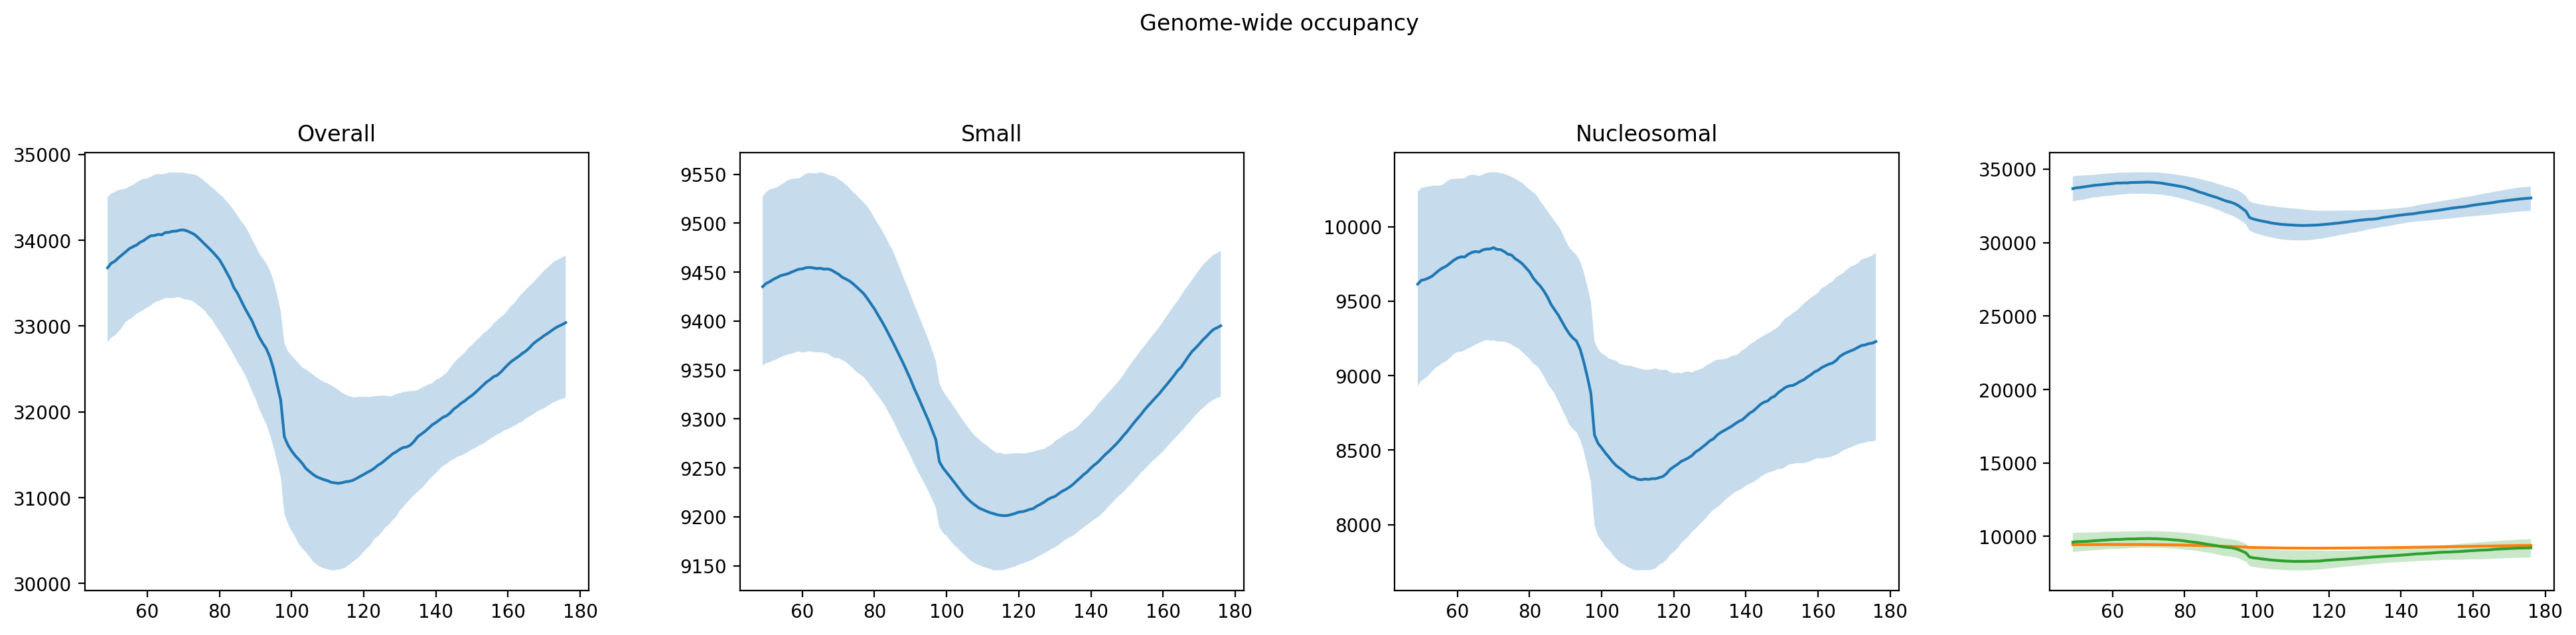

In [189]:
def plot_curve(curve):
    lower = curve.quantile(0.25, axis=0)[t_indices].astype(float)
    upper = curve.quantile(0.75, axis=0)[t_indices].astype(float)
    x = t_indices
    plt.fill_between(x, lower, upper, alpha=0.25)
    plt.plot(curve.median(axis=0)[t_indices])
    
fig = plt.figure(figsize=(24, 5))
plt.subplot(1, 4, 1)
plot_curve(overall_win_10k_occupancy_curves)
plt.title("Overall")

plt.subplot(1, 4, 2)
plot_curve(small_win_10k_occupancy_curves)
plt.title("Small")

plt.subplot(1, 4, 3)
plot_curve(nuc_win_10k_occupancy_curves)
plt.title("Nucleosomal")

plt.suptitle("Genome-wide occupancy")
plt.subplots_adjust(wspace=0.3, top=0.77)

plt.subplot(1, 4, 4)
plot_curve(overall_win_10k_occupancy_curves)
plot_curve(small_win_10k_occupancy_curves)
plot_curve(nuc_win_10k_occupancy_curves)

plt.suptitle("Genome-wide occupancy")
plt.subplots_adjust(wspace=0.3, top=0.77)

Observation: Overall, small and nucleosomal sized fragments follow the same overall curve
large occupancy in G1 followed by a drop in S.

The absolute scale of which is greater in nucleosomes than in small fragments. That is, 
the nucleosomal occupancy changes is greater than the small fragments, but when examined 
individually, the curves and quantiles are similar in shape and range.

This appears to be a total occupancy shape of the genome.

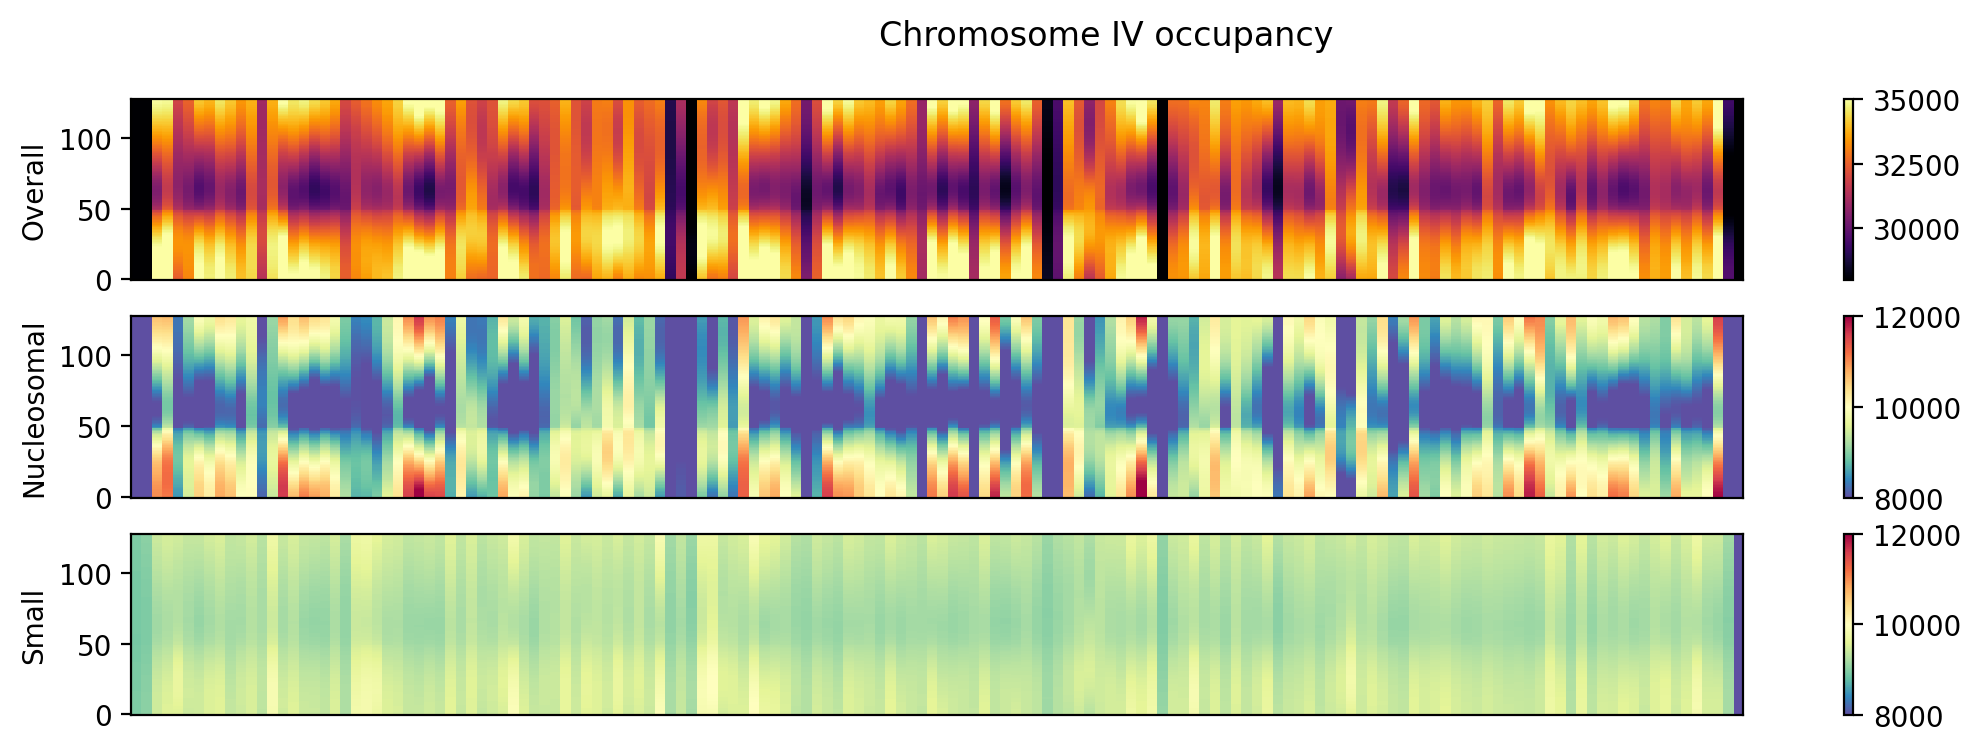

In [307]:
chrom = 4

plt.figure(figsize=(13, 4))

plt.subplot(3, 1, 1)
plt.imshow(overall_win_10k_occupancy_curves.loc[chrom].astype(float)[t_indices].T, 
           vmin=28000, vmax=35000, aspect='auto', 
          origin='lower', interpolation='none', cmap='inferno')
plt.colorbar()
plt.xticks([])
plt.ylabel(f"Overall")

plt.subplot(3, 1, 2)
plt.imshow(nuc_win_10k_occupancy_curves.loc[chrom].astype(float)[t_indices].T, 
           vmin=8000, vmax=12000, aspect='auto', 
          origin='lower', interpolation='none', cmap='Spectral_r')
plt.colorbar()
plt.xticks([])
plt.ylabel(f"Nucleosomal")

plt.subplot(3, 1, 3)
plt.imshow(small_win_10k_occupancy_curves.loc[chrom].astype(float)[t_indices].T, 
           vmin=8000, vmax=12000, aspect='auto', 
          origin='lower', interpolation='none', cmap='Spectral_r')
plt.ylabel(f"Small")
plt.colorbar()
plt.xticks([])
plt.suptitle(f'Chromosome IV occupancy')

save_figure_for_paper('output/figures/Replication/ChrIV_Nucleosome_occupancy_10kb_replication.png')


In examining an individual chromosome, IV, the variation in the occupancy curve is notable. We can also see variation in the timing in which the occupancy rises back up to the peak value. The trough position is likely strongly correlated with replication timing (as per the previous deconvolution to identify replication timing).


In [285]:
from src.reference_data import load_chrom_replication_timing
chrom_replication_timing = load_chrom_replication_timing()
chrom_replication_timing.head()

replication_index  replication_time_1  replication_time_2  \
chr start                                                              
1   0                    123             14.8086             12.7944   
    2000                 123             14.8086             12.7944   
    4000                 123             14.8086             12.7944   
    6000                 123             14.8086             12.7944   
    8000                 122             14.2275             12.2867   

           replication_time  
chr start                    
1   0               13.8015  
    2000            13.8015  
    4000            13.8015  
    6000            13.8015  
    8000            13.2571

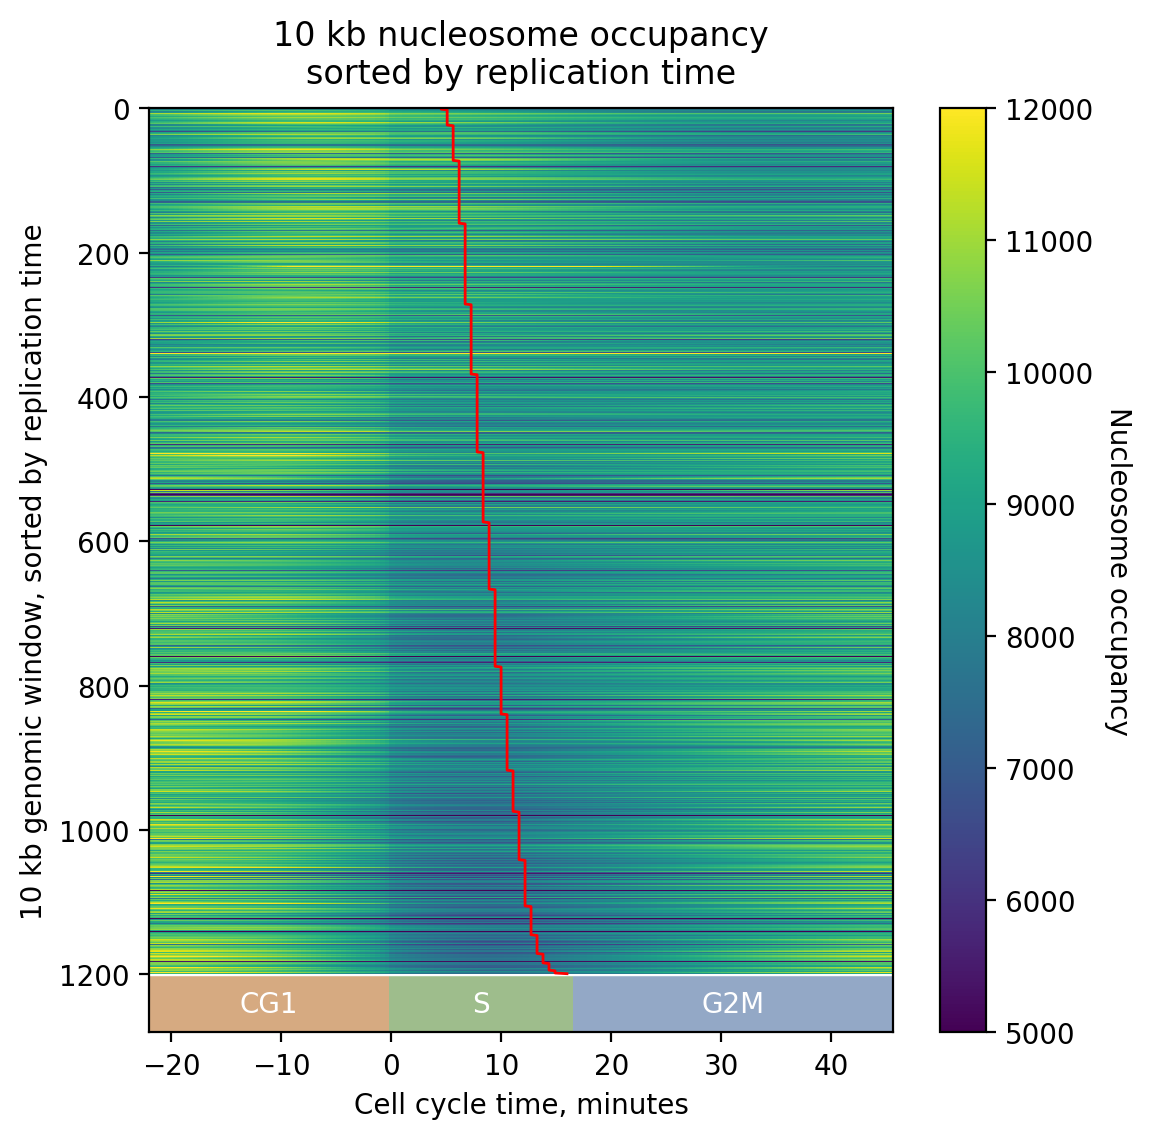

In [306]:
from src.chromatin_model import draw_phase_label_annotations
from src.plot_helpers import plot_heatmap_cell_cycle_tps

occ_repl_df = nuc_win_10k_occupancy_curves.join(chrom_replication_timing, how='inner')

plt.figure(figsize=(6, 6))
plot_data = occ_repl_df.sort_values('replication_time')[t_indices].astype(float)

ax = plt.gca()
im1, im2 = plot_heatmap_cell_cycle_tps(ax, analysis.config, plot_data, vmin=5000, vmax=12000,
                           cmap='viridis')
cbar = plt.colorbar(im1)
cbar.ax.set_ylabel("Nucleosome occupancy", rotation=270, va='bottom')
plt.ylabel("10 kb genomic window, sorted by replication time")
plt.title("10 kb nucleosome occupancy\nsorted by replication time", pad=9)

plt.plot(occ_repl_df.replication_time.sort_values(), np.arange(len(occ_repl_df)),
        c='red', lw=1)

from src.figure_configs import save_figure_for_paper

save_figure_for_paper('output/figures/Replication/Nucleosome_occupancy_10kb_replication.png')


10 kb nucleosome occupancy through the top branch (G1, S, G2M) sorted by replication time.

Summary of observations
1. The first 20% of the genome shows an increase in nucleosome occupancy through the end of G1 into S phase. The peak occupancy occurs in mid-to late G1.
2. The last 40% of the genome shows an immediate drop off in nucleosome occupancy going into S-phase, (for the last 30% this starts inside G1). The peak occupancy occurs at the end of G2M into G1.

Biological reasoning, possible sources/explanations:
1. Copy number - early replicating regions double the number of available DNA, where nucleosomes can bind effectively doubling the occupancy early on in S (could this begin earlier in G1? And thus late replicating regions reduce in occupancy as a way to keep the total total genome occupancy constant (normalization constraint prior to deconvolution, does it carry into the deconvolution results?).
2. Early replicating regions require a larger number of histones and nucleosome for genome stability and thus preempt replication by overproducing histones to be used following replication. Available histones are depleted following early replication, so later replicating regions take longer to reach deposit nucleosomes and reach maximal occupancy.

todo: review literature on histone deposition (Bonnie?) Yulong


In [294]:
# This is the same story as the gene bodies, but perhaps cleaner because the 10k windows
# incoporate more of the genome

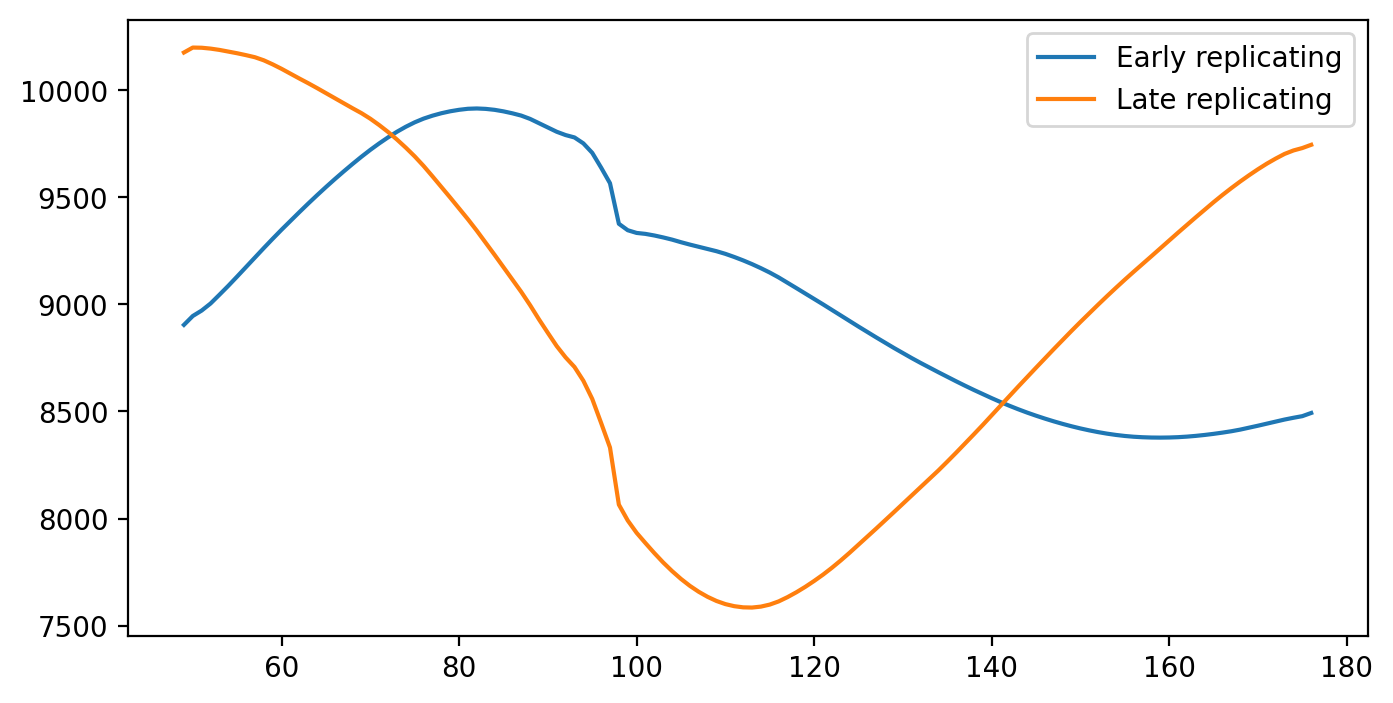

In [304]:
plt.figure(figsize=(8, 4))
plt.plot(occ_repl_df.sort_values('replication_time')[t_indices].head(200).mean(axis=0), 
         label="Early replicating")
plt.plot(occ_repl_df.sort_values('replication_time')[t_indices].tail(200).mean(axis=0), 
         label="Late replicating")
plt.legend()

In [305]:
# Todo: Finalize the messaging of this story, literature review and feedback
# from Dave and Alex will help. This is the entropy/occupancy replication story
# Check what Yulong has written about this phenomena
